The goal of this script is to create a function that takes in user inputted parameters for a cell (its width, length, and radius of holes) and outputs the band diagram for that strucutre. It is to note that this script will be made with the material being Silicon in a vacuum. 

In [57]:
# Importing Libraries: 

import meep as mp
import matplotlib.pyplot as plt
import numpy as np 
from IPython.display import Video 

%matplotlib inline 

Maxwell's Equations are scale invariant, because of this I will choose the characteristic length scale to be a tenth of a micron

In [ ]:
def unitcellbandstrucuture(width, length, diameter):
    # width - width of our beam in nanometers
    # length - length of our beam in nanometers
    # diameter - diameter of the holes in patterned into the beam in nanometers

    # Parameters for the computational cell: 
    pml_padding = length  
    padding_to_pml = 4*length
    sx = 1       # We will scale the dimensions of everything else by the length (for example we scaled the paddings above by the length)
    sy = 2*(pml_padding + padding_to_pml + width)/length  
    res = 64     

    cell = mp.Vector3(sx,sy)

    # For the silicon we want to use and our approximate target wavelength is below: 
    eps_silicon = 12
    thickness = 220
    wavelength = 1540 

    # Defining our waveguide given the parameters, meep assumes periodic structure: 
    beam = mp.Block(size = (1e20, width/length, 1e20), material = mp.Medium(epsilon = eps_silicon) )
    holes = mp.Cylinder(radius = (diameter/2)/length, material = mp.Medium(epsilon = 1))

    geometry = [beam,holes]

    # Other things for simulation: It is to note that say we want to run for a certian number of periods, then we would divide our time by the frequency below
    fcenter = length/wavelength           # In meep units, the frequency is specified by 1/lambda according to https://meep.readthedocs.io/en/latest/Introduction/#units-in-meep
    df = .5*fcenter

    sym = mp.Mirror(direction=mp.Y, phase=-1)
    # Broad source to excite modes
    source = mp.Source(mp.GaussianSource(fcenter, fwidth = df), mp.Hz, mp.Vector3(0, 0))
    pml_layers = [mp.PML(pml_padding/length, direction =mp.Y)]

    simulation = mp.Simulation(
        cell_size = cell, 
        boundary_layers = pml_layers, 
        geometry = geometry, 
        sources = [source], 
        resolution = res, 
        symmetries=[sym]
    )

    f = plt.figure(dpi=200)
    simulation.plot2D(ax = f.gca())
    f.gca().xaxis.set_visible(False)
    f.suptitle('Geometry of Simulation')
    plt.show()


    h = mp.Harminv(mp.Hz, mp.Vector3(), fcenter, df)
    

    simulation.run(
    mp.at_beginning(mp.output_epsilon), 
    mp.after_sources(h),
    until_after_sources = 400
)
    
    simulation.sources = [
   mp.Source(mp.GaussianSource(fcenter, df), mp.Hz, mp.Vector3())
]   
    
    simulation.restart_fields()
    k_interp = 29
    kpts = mp.interpolate(k_interp, [mp.Vector3(0), mp.Vector3(.5)])
    kx = []
    modes = {}
    for k in kpts: 
        kx.append(k)
        H = simulation.run_k_point(300,k)
        print('\n \n \n')
        print(H)
        print(H.modes)
        print(H.modes[0])
        print(H.modes[0].freq)
        print('\n \n \n')
        #for i in range(len(H)): 
            #dictionary_addition( modes, i, H.modes[i].freq)
    #all_freqs = simulation.run_k_points(300, kpts)

    kx = [k.x for k in kpts]
    fig = plt.figure(dpi=100, figsize=(5, 5))
    ax = plt.subplot(111)
    for i in range(len(all_freqs)):
        for ii in range(len(all_freqs[i])):
            plt.scatter(kx[i], np.real(all_freqs[i][ii]), color="b")

    ax.fill_between(kx, kx, 1.0, interpolate=True, color="gray", alpha=0.3)
    plt.xlim(0, .5)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.xlabel("$k_x(2\pi)$")
    plt.ylabel("$\omega(2\pi c)$")
    plt.tight_layout()
    plt.show()
    
def dictionary_addition(dictionary, key, val):
    if key in dictionary: 
        dictionary[key] = [val]
    else: 
        dictionary[key].append(val)


<>:93: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\o'
<>:93: SyntaxWarning: invalid escape sequence '\p'
<>:94: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1104205/3843162306.py:93: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$k_x(2\pi)$")
/tmp/ipykernel_1104205/3843162306.py:94: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega(2\pi c)$")


     block, center = (0,0,0)
          size (1e+20,0.833333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)


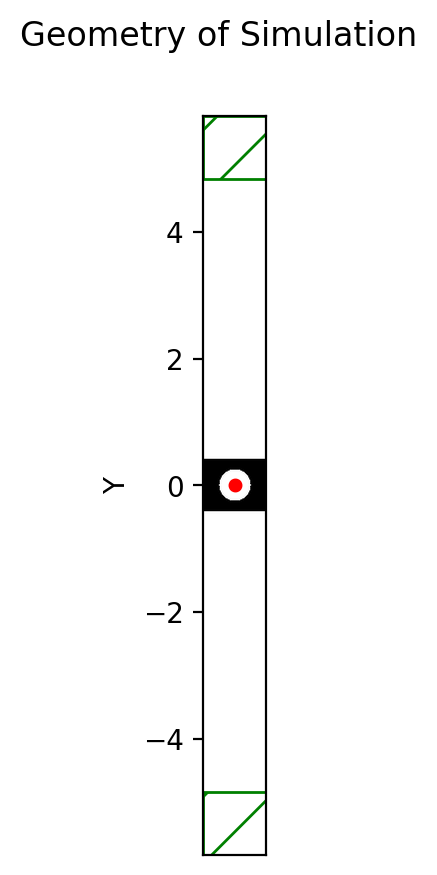

-----------
Initializing structure...
Padding y to even number of grid points.
Halving computational cell along direction y
time for choose_chunkdivision = 0.000627995 s
Working in 2D dimensions.
Computational cell is 1 x 11.6719 x 0 with resolution 64
     block, center = (0,0,0)
          size (1e+20,0.833333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     cylinder, center = (0,0,0)
          radius 0.25, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.031261 s
-----------
creating output file "./eps-000000000.h5"...
Meep progress: 289.0625/451.3333320617676 = 64.0% done in 4.0s, 2.2s to go
on time step 37088 (time=289.75), 0.000107853 s/step
harminv0:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv0:, 0.3792949272564054, -1.881878825330743e-06, 100775.59780974308, 4.701464758265825, 0.3927879521283037-4.685028121354064i, 1.7509042968739182e-13+0

/tmp/ipykernel_1104205/3843162306.py:93: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$k_x(2\pi)$")
/tmp/ipykernel_1104205/3843162306.py:94: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega(2\pi c)$")


KeyboardInterrupt: 

In [59]:
unitcellbandstrucuture(500,600,300)